# Setup and Imports

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm
import warnings
import os
from pathlib import Path
import random
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from torch_geometric.data import Data

# --- Local Imports from 'src' folder ---
from src.data_loader import (
    load_wikispeedia_file,
    load_shortest_path_matrix,
    get_article_text,
    get_article_html,
    find_absolute_link_position_from_df
)
from src.feature_extractor import FeatureExtractor, EMBEDDING_DIM
from src.evaluation import calculate_mrr
from src.html_processor import HtmlProcessor
from src.heuristic import expand_paths_to_steps, compute_mrr_next_link
from src.gnn_utils import create_feature_dataset, prepare_hard_listwise_data, evaluate_hybrid_mrr
from src.gnn_model import HybridGraphSAGE

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## Load .tsv and .txt files

This section loads all the core datasets from the Wikispeedia dataset:
- **articles.tsv**: List of all Wikipedia articles in the dataset
- **links.tsv**: Directed graph edges representing hyperlinks between articles
- **paths_finished.tsv**: Human navigation paths where players successfully reached their goal
- **paths_unfinished.tsv**: Paths where players gave up or timed out
- **shortest-path-distance-matrix.txt**: Pre-computed shortest path distances between all article pairs

These datasets form the foundation for our feature engineering and model training.

In [2]:
articles_df = load_wikispeedia_file("articles.tsv", columns=["article_name"])
articles_df["article_id"] = articles_df["article_name"]
print("Articles:", articles_df.shape)

categories_df = load_wikispeedia_file("categories.tsv", columns=["article", "category"])
print("Categories:", categories_df.shape)

links_df = load_wikispeedia_file("links.tsv", columns=["source", "target"])
print("Links:", links_df.shape)

paths_finished_df = load_wikispeedia_file("paths_finished.tsv", 
    columns=["hashedIpAddress", "timestamp", "durationInSec", "path", "rating"]
)
print("Finished paths:", paths_finished_df.shape)

paths_unfinished_df = load_wikispeedia_file("paths_unfinished.tsv",
    columns=["session_id", "timestamp", "session_time", "path", "rating", "type"]
)
print("Unfinished paths:", paths_unfinished_df.shape)

dist_matrix = load_shortest_path_matrix()
print("Distance Matrix:", dist_matrix.shape)

Loading: data\wikispeedia_paths-and-graph\articles.tsv
Articles: (4604, 2)
Loading: data\wikispeedia_paths-and-graph\categories.tsv
Categories: (5204, 2)
Loading: data\wikispeedia_paths-and-graph\links.tsv
Links: (119882, 2)
Loading: data\wikispeedia_paths-and-graph\paths_finished.tsv
Finished paths: (51318, 5)
Loading: data\wikispeedia_paths-and-graph\paths_unfinished.tsv
Unfinished paths: (24875, 6)
Loading distance matrix...
Distance Matrix: (4604, 4604)


## Load plain article text & html text into articles dataframe

In [3]:
# Load text content (can take a moment)
articles_df["plaintext"] = articles_df["article_name"].apply(lambda x: get_article_text(x))
articles_df["plaintext_length"] = articles_df["plaintext"].apply(lambda x: len(x) if isinstance(x, str) else 0)

# Load HTML content
articles_df["html_content"] = articles_df["article_name"].apply(lambda x: get_article_html(x))

ERROR reading file data\wikispeedia_articles_html\wpcd\wp\d\Directdebit.htm: 'utf-8' codec can't decode byte 0xf4 in position 6145: invalid continuation byte
ERROR reading file data\wikispeedia_articles_html\wpcd\wp\d\Donation.htm: 'utf-8' codec can't decode byte 0xf4 in position 5270: invalid continuation byte
ERROR reading file data\wikispeedia_articles_html\wpcd\wp\f\Friend_Directdebit.htm: 'utf-8' codec can't decode byte 0xa3 in position 1473: invalid start byte
ERROR reading file data\wikispeedia_articles_html\wpcd\wp\s\Sponsorship_Directdebit.htm: 'utf-8' codec can't decode byte 0xa3 in position 1495: invalid start byte
ERROR reading file data\wikispeedia_articles_html\wpcd\wp\w\Wowpurchase.htm: 'utf-8' codec can't decode byte 0xa3 in position 1530: invalid start byte


### Load html text for articles with errors manually (Fixing encoding issues)

In [4]:
# This block preserves your manual fixes for specific files with encoding issues
manual_fixes = {
    "Directdebit": "./data/wikispeedia_articles_html/wpcd/wp/d/Directdebit.htm",
    "Donation": "./data/wikispeedia_articles_html/wpcd/wp/d/Donation.htm",
    "Friend_Directdebit": "./data/wikispeedia_articles_html/wpcd/wp/f/Friend_Directdebit.htm",
    "Sponsorship_Directdebit": "./data/wikispeedia_articles_html/wpcd/wp/s/Sponsorship_Directdebit.htm",
    "Wowpurchase": "./data/wikispeedia_articles_html/wpcd/wp/w/Wowpurchase.htm"
}

for name, path in manual_fixes.items():
    file_path = Path(path)
    if file_path.exists():
        try:
            # Try utf-8 first
            html_text = file_path.read_text(encoding="utf-8")
        except UnicodeDecodeError:
            # Fallback to latin-1 as per your original code
            html_text = file_path.read_text(encoding="latin-1")
        
        articles_df.loc[articles_df["article_name"] == name, "html_content"] = html_text
        print(f"Manually loaded: {name}")

nan_html = articles_df[articles_df["html_content"].isna()]
print(f"Articles with missing HTML: {len(nan_html)}")

articles_df["html_length"] = articles_df["html_content"].apply(
    lambda x: len(x) if isinstance(x, str) else 0
)
display(articles_df.sort_values(by="html_length", ascending=True).head())

Manually loaded: Directdebit
Manually loaded: Donation
Manually loaded: Friend_Directdebit
Manually loaded: Sponsorship_Directdebit
Manually loaded: Wowpurchase
Articles with missing HTML: 0


,article_name,article_id,plaintext,plaintext_length,html_content,html_length
4545,Wowpurchase,Wowpurchase,[1x1.gif] [1x1.gi...,871,"<html>\n<head>\n<meta name=""keywords"" content=...",3118
1292,Eastern_Roman_Empire,Eastern_Roman_Empire,#copyright\n\nEastern Roman Empire\n\n2007 ...,1438,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",5367
3786,Soil_profile,Soil_profile,#copyright\n\nSoil profile\n\n2007 Schools ...,1577,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",5415
297,Apaochi,Apaochi,#copyright\n\nApaochi\n\n2007 Schools Wikip...,1635,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",5547
1041,Corn_oil,Corn_oil,#copyright\n\nCorn oil\n\n2007 Schools Wiki...,1834,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",5629


## Indegree and Outdegree Analysis

This section computes graph topology features for each article:
- **outdegree**: Number of outgoing links (how many articles this article links to)
- **indegree**: Number of incoming links (how many articles link to this article)

These features help identify "hub" articles that are central to the Wikipedia graph structure, which humans often use as navigation waypoints.

In [5]:
outdegree = links_df["source"].value_counts().rename("outdegree")
indegree = links_df["target"].value_counts().rename("indegree")

articles_df = articles_df.drop(columns=["outdegree", "indegree"], errors="ignore")
articles_df = (
    articles_df
    .merge(outdegree, how="left", left_on="article_name", right_index=True)
    .merge(indegree, how="left", left_on="article_name", right_index=True)
)

articles_df[["outdegree", "indegree"]] = articles_df[["outdegree", "indegree"]].fillna(0).astype(int)
isolated_df = articles_df[(articles_df["outdegree"] == 0) | (articles_df["indegree"] == 0)]

print(f"Articles with 0 indegree or outdegree: {len(isolated_df)}")
display(isolated_df.head())

Articles with 0 indegree or outdegree: 474


,article_name,article_id,plaintext,plaintext_length,html_content,html_length,outdegree,indegree
0,Áedán_mac_Gabráin,Áedán_mac_Gabráin,#copyright\n\nÁedán mac Gabráin\n\n2007 Sch...,11612,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",19712,11,0
1,Åland,Åland,#copyright\n\nÅland\n\n2007 Schools Wikiped...,17238,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",38350,19,0
2,Édouard_Manet,Édouard_Manet,#copyright\n\nÉdouard Manet\n\n2007 Schools...,18996,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",36440,20,0
3,Éire,Éire,#copyright\n\nÉire\n\n2007 Schools Wikipedi...,13083,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",19985,8,0
4,Óengus_I_of_the_Picts,Óengus_I_of_the_Picts,#copyright\n\nÓengus I of the Picts\n\n2007...,12944,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",22697,10,0


## Link Positions Analysis

This section extracts the visual position of each link within its source article:
- **link_position_absolute**: Character position where the link appears in the HTML
- **link_position_relative**: Normalized position (0 = beginning, 1 = end of article)

Research suggests humans are more likely to click links that appear earlier in an article, so this feature captures visual ordering bias.

In [6]:
# Create lookup for speed
articles_lookup = dict(zip(articles_df["article_name"], articles_df["html_content"]))

# Use imported function to find positions
links_df["link_position_absolute"] = links_df.apply(
    lambda row: find_absolute_link_position_from_df(row, articles_lookup), axis=1
)

links_df["html_length"] = links_df["source"].map(
    articles_df.set_index("article_name")["html_length"]
)

links_df["link_position_relative"] = (
    links_df["link_position_absolute"] / links_df["html_length"]
).where(links_df["html_length"] > 0)

display(links_df.sort_values(by="link_position_relative").head())

,source,target,link_position_absolute,html_length,link_position_relative
19356,Byzantine_Empire,History,2593.0,156402,0.016579
44052,Germany,Europe,2706.0,159886,0.016925
44051,Germany,Euro,2706.0,159886,0.016925
54564,Indo-Greek_Kingdom,Mythology,2692.0,158085,0.017029
112559,United_States,North_America,2791.0,155232,0.017980


# Descriptive Analysis

This section provides an overview of the dataset statistics:
- Total number of articles (nodes) and links (edges) in the graph
- Distribution of path lengths in finished games

This helps us understand the scale of the problem and the typical navigation patterns of human players.

In [7]:
print("--- Descriptive Analysis ---")
print(f"Total articles (nodes): {len(articles_df)}")
print(f"Total links (edges): {len(links_df)}")

paths_finished_df['path_length'] = paths_finished_df['path'].apply(lambda x: len(x.split(';')))
print(f"\n--- Path Length Statistics ---")
print(paths_finished_df['path_length'].describe())

--- Descriptive Analysis ---
Total articles (nodes): 4604
Total links (edges): 119882

--- Path Length Statistics ---
count    51318.000000
mean         6.757434
std          4.680718
min          1.000000
25%          5.000000
50%          6.000000
75%          8.000000
max        435.000000
Name: path_length, dtype: float64


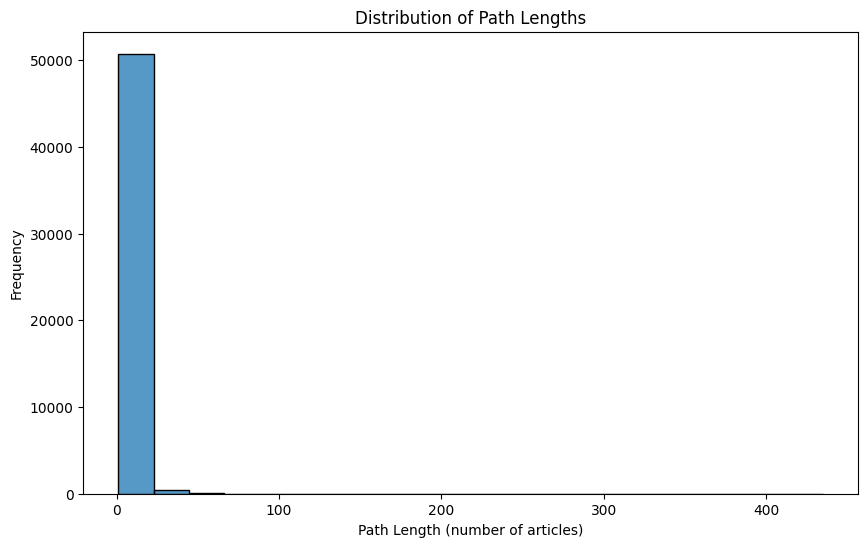

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(paths_finished_df['path_length'], kde=False, bins=20)
plt.title('Distribution of Path Lengths')
plt.xlabel('Path Length (number of articles)')
plt.ylabel('Frequency')
plt.show()

# Pre-computation and Setup

This section performs expensive computations that are needed for feature generation but only need to be done once:

1. **Create lookup dictionaries**: Maps between article IDs, names, and matrix indices for efficient access
2. **Build links map**: Groups all outgoing links by source article for fast candidate retrieval
3. **Compute topology features**: Calculates PageRank (article centrality) and out-degree for all articles
4. **Generate embeddings**: Creates SBERT embeddings for all articles using the first paragraph of text

These pre-computed values are stored in memory and reused throughout the feature generation process, which significantly speeds up the pipeline.

In [9]:
HTML_DIR = "./data/wikispeedia_articles_html/wpcd/wp"

# 1. Link Positions
if os.path.exists(HTML_DIR):
    html_proc = HtmlProcessor(HTML_DIR)
    link_position_map = html_proc.precompute_positions(articles_df['article_id'].tolist())
    print("Link positions extraction complete.")
else:
    print("HTML Directory not found. Using defaults.")
    link_position_map = {}

# 2. Graph Topology
extractor = FeatureExtractor()
links_map = links_df.groupby('source')['target'].apply(list).to_dict()
pagerank_map, out_degree_map = extractor.create_topology_maps(links_df)

# 3. Embeddings
embedding_map = {}
article_id_to_name = pd.Series(articles_df.article_name.values, index=articles_df.article_id).to_dict()

# Mapping for later
article_id_to_index = {aid: i for i, aid in enumerate(articles_df['article_id'])}

print("Generating Embeddings...")
for article_id in tqdm(articles_df['article_id'], desc="Embeddings"):
    text = get_article_text(article_id)
    # Strategy 'first_para' as per your original code
    embedding_map[article_id] = extractor.get_text_embedding(text, strategy='first_para')

Indexing HTML files in data\wikispeedia_articles_html\wpcd\wp...
Extracting link positions from HTML...


Parsing HTML: 100%|██████████| 4604/4604 [00:44<00:00, 103.51it/s]


Link positions extraction complete.
Building graph for PageRank and Out-Degree...
Calculating PageRank...
Graph feature maps created.
Generating Embeddings...


Embeddings:   0%|          | 0/4604 [00:00<?, ?it/s]

Loading SentenceTransformer model: all-MiniLM-L6-v2...
Model loaded successfully.


## Logistic Regression Baseline (PoC)

This section splits the finished paths into training (80%) and validation (20%) sets, then generates feature datasets for both.

The feature generation process is computationally expensive because:
- We process every step of every path
- For each step, we generate features for ALL candidate links (not just the clicked one)
- This creates a highly imbalanced dataset (~3% positive samples) which reflects the real-world ranking problem

The resulting datasets are large (millions of samples) because each path step generates many negative examples.

### Model training

This section trains our Proof-of-Concept (PoC) model using Logistic Regression.

**Preprocessing:**
- Replace infinite values (from unreachable nodes in distance matrix) with a large finite value
- Standardize features using StandardScaler (important for Logistic Regression)

**Model:**
- Logistic Regression with `class_weight='balanced'` to handle the extreme class imbalance (~98.5% negative, ~1.5% positive)
- This allows the model to learn from the rare positive examples effectively

**Feature Importance:**
- The model coefficients show which features are most predictive of human link choices
- Positive coefficients indicate features that increase the likelihood of a link being clicked

In [10]:
train_paths_df, val_paths_df = train_test_split(
    paths_finished_df, 
    test_size=0.2, 
    random_state=42
)

print("Generating training data for LogReg...")
# Using the imported function instead of defining it here
X_train_df, y_train, q_train = create_feature_dataset(
    train_paths_df, links_map, embedding_map, dist_matrix, 
    article_id_to_index, pagerank_map, out_degree_map, 
    link_position_map, extractor
)

print("Generating validation data for LogReg...")
X_val_df, y_val, q_val = create_feature_dataset(
    val_paths_df, links_map, embedding_map, dist_matrix, 
    article_id_to_index, pagerank_map, out_degree_map, 
    link_position_map, extractor
)

print(f"X_train: {X_train_df.shape}")
display(X_train_df.head())

# Scale and Train
X_train_df.replace([np.inf, -np.inf], 1000, inplace=True)
X_val_df.replace([np.inf, -np.inf], 1000, inplace=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_df)
X_val_scaled = scaler.transform(X_val_df)

print("Training Logistic Regression...")
model_poc = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_poc.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    'feature': X_train_df.columns,
    'coef': model_poc.coef_[0]
}).sort_values('coef', ascending=False)

display(feature_importance)

print("Calculating MRR on validation set...")
mrr_score = calculate_mrr(
    model=model_poc,
    X_val=X_val_scaled,
    y_val=y_val,
    query_groups=q_val
)
print(f"Logistic Regression MRR: {mrr_score:.4f}")

Generating training data for LogReg...


Processing Paths: 100%|██████████| 41054/41054 [1:04:35<00:00, 10.59it/s]


Generating validation data for LogReg...


Processing Paths: 100%|██████████| 10264/10264 [15:41<00:00, 10.90it/s]


X_train: (14057674, 8)


,sim_source_candidate,sim_candidate_goal,link_position,pagerank,out_degree,is_closer,dist_candidate_goal,dist_source_goal
0,1.0,1.0,0.567568,0.002362,93.0,1.0,2.0,3.0
1,1.0,1.0,0.324324,0.000485,21.0,0.0,3.0,3.0
2,1.0,1.0,0.135135,0.002883,29.0,1.0,2.0,3.0
3,1.0,1.0,0.405405,0.001169,37.0,0.0,3.0,3.0
4,1.0,1.0,0.432432,0.001214,21.0,0.0,3.0,3.0


Training Logistic Regression...


,feature,coef
7,dist_source_goal,1.351392
3,pagerank,0.283925
5,is_closer,0.149327
0,sim_source_candidate,0.000000
1,sim_candidate_goal,0.000000
4,out_degree,-0.235511
2,link_position,-0.460570
6,dist_candidate_goal,-1.364834


Calculating MRR on validation set...
Logistic Regression MRR: 0.4735


## Evaluation

This section evaluates the model using Mean Reciprocal Rank (MRR), which is appropriate for ranking tasks.

**MRR Explanation:**
- For each path step (query), we rank all candidate links by the model's predicted probability
- MRR = average of (1 / rank_of_correct_link) across all queries
- MRR of 0.4735 means: on average, the correct human-clicked link is ranked in the top 2-3 positions
- Higher MRR (closer to 1.0) means the model better predicts human choices

This metric is better than accuracy for this task because:
- We care about ranking quality, not just binary classification
- The problem is inherently a ranking problem (choose the best link from many candidates)

# Heuristic Approach
Applying the heuristic that combines semantic similarity and hub-seeking behavior

$$
\text{Score}(c)
=
\alpha \cdot \cos(\mathbf{v}_c, \mathbf{v}_g)
\;+\;
(1 - \alpha) \cdot 
\frac{\text{outdeg}(c)}{\max_{c'} \text{outdeg}(c')}
$$

- c = candidate next article  
- g = goal article  
- $v_c$ = embedding vector of the candidate article  
- $v_g$ = embedding vector of the goal article  
- $cos(v_c, v_g)$ = cosine similarity between candidate and goal  
- $outdeg(c)$ = number of outgoing links of candidate (hub measure)  
- $max_{c'} {outdeg}(c')$ = maximum outdegree among all candidates (used to normalize)  
- $\alpha$ in [0,1] = controls trade-off between semantic similarity and hub-seeking  
  - Early in the game → larger $\alpha$ for hub-seeking  
  - Later in the game → smaller $\alpha$ to emphasize semantic closeness

In [11]:
# Using imported function to expand paths
formatted_paths_finished_df = expand_paths_to_steps(paths_finished_df)
display(formatted_paths_finished_df.head())

# Heuristic Evaluation Loop
selected_ids = set()
ranks = []

print("Evaluating Heuristic on 1000 random samples...")
for _ in range(1000):
    while True:
        i = random.randint(0, len(formatted_paths_finished_df) - 1)
        if i not in selected_ids:
            selected_ids.add(i)
            break

    row = formatted_paths_finished_df.iloc[i]
    current_article_id = row["current_article"]
    goal_article_id = row["goal_article"]
    next_article_id = row["next_article"]
    path_length = row["path_length"]
    step_number = row["step_number"]
    alpha = step_number / path_length

    # Using imported computation function
    rank = compute_mrr_next_link(
        current_article_id, goal_article_id, next_article_id, 
        links_map, embedding_map, articles_df, alpha=alpha
    )
    ranks.append(rank)

mrr = sum(ranks) / len(ranks)
print(f"Heuristic MRR: {mrr:.4f}")

,step_id,game_id,current_article,next_article,goal_article,path_length,step_number
0,0,0,14th_century,15th_century,African_slave_trade,9,1
1,1,0,15th_century,16th_century,African_slave_trade,9,2
2,2,0,16th_century,Pacific_Ocean,African_slave_trade,9,3
3,3,0,Pacific_Ocean,Atlantic_Ocean,African_slave_trade,9,4
4,4,0,Atlantic_Ocean,Accra,African_slave_trade,9,5


Evaluating Heuristic on 1000 random samples...
Heuristic MRR: 0.1810


# Graph Neural Network Approach
Applying a Graph Neural Network (GraphSAGE) to learn contextualized node embeddings that capture both semantic content and local graph topology.

$$
\mathbf{h}_i = \sigma \left( \mathbf{W} \cdot \text{AGG} \left( \{ \mathbf{x}_i \} \cup \{ \mathbf{x}_j, \forall j \in \mathcal{N}(i) \} \right) \right)
$$

$$
\text{Score}(c) = \text{MLP} \left( \mathbf{h}_s \;\|\; \mathbf{h}_c \;\|\; \mathbf{h}_g \right)
$$

- $s, c, g$ = source (current), candidate, and goal articles
- $\mathbf{x}_i$ = initial SBERT embedding of article $i$ (semantic features)
- $\mathbf{h}_i$ = learned GNN embedding of article $i$ (contextualized features)
- $\mathcal{N}(i)$ = set of immediate neighbors of article $i$ in the graph
- $\text{AGG}$ = aggregation function (e.g., mean) combining neighbor information
- $\|$ = concatenation operation
- $\text{MLP}$ = Multi-Layer Perceptron (neural network) that outputs the likelihood of clicking the link
- **Intuition**: Unlike the heuristic, the GNN learns the optimal non-linear combination of semantic similarity ($\mathbf{x}$) and graph structure ($\mathcal{N}$) directly from historical human paths.

### Build Graph Structure

First, we construct the Wikipedia graph from the links data. This graph will be used by the GNN to learn node representations that incorporate both semantic features (embeddings) and graph structure (neighborhood information).



In [13]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {DEVICE}")

# Build Graph Data object for PyG
x_list = [embedding_map.get(aid, np.zeros(384)) for aid in articles_df['article_id']]
x = torch.tensor(np.array(x_list), dtype=torch.float)

src_list = [article_id_to_index[s] for s in links_df['source'] if s in article_id_to_index]
dst_list = [article_id_to_index[t] for t in links_df['target'] if t in article_id_to_index]
edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)

pyg_data = Data(x=x, edge_index=edge_index).to(DEVICE)

# Hyperparameters
BATCH_SIZE = 128
NEG_SAMPLES = 20
EPOCHS = 10
HIDDEN_DIM = 384
LR = 0.001

print(f"Generating GNN Training Data (NegSamples={NEG_SAMPLES})...")
train_dataset = prepare_hard_listwise_data(
    train_paths_df, article_id_to_index, links_map, dist_matrix,
    pagerank_map, out_degree_map, link_position_map, neg_samples=NEG_SAMPLES
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

model = HybridGraphSAGE(in_channels=384, hidden_channels=HIDDEN_DIM, num_explicit_feats=5).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
criterion = torch.nn.CrossEntropyLoss()

train_losses = []
val_mrrs = []
best_mrr = 0.0

print("Starting GNN Training...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        src, goal, cands, feats = batch
        B, N_OPTS = cands.shape
        
        flat_src = src.repeat_interleave(N_OPTS).to(DEVICE)
        flat_goal = goal.repeat_interleave(N_OPTS).to(DEVICE)
        flat_cands = cands.view(-1).to(DEVICE)
        flat_feats = feats.view(-1, 5).to(DEVICE)
        
        optimizer.zero_grad()
        flat_scores = model(pyg_data.x, pyg_data.edge_index, flat_src, flat_cands, flat_goal, flat_feats)
        scores = flat_scores.view(B, N_OPTS)
        targets = torch.zeros(B, dtype=torch.long).to(DEVICE)
        
        loss = criterion(scores, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # Sampled validation for speed
    val_mrr = evaluate_hybrid_mrr(
        model, pyg_data, val_paths_df, article_id_to_index, links_map, dist_matrix, 
        pagerank_map, out_degree_map, link_position_map, DEVICE,
        sample_size=2000
    )
    val_mrrs.append(val_mrr)
    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Val MRR: {val_mrr:.4f}")
    
    if val_mrr > best_mrr:
        best_mrr = val_mrr
        torch.save(model.state_dict(), "best_hybrid_sage.pth")

print(f"Best Sampled MRR: {best_mrr:.4f}")

Running on cuda
Generating GNN Training Data (NegSamples=20)...


Prep GNN Data: 100%|██████████| 41054/41054 [00:13<00:00, 2983.80it/s]


Starting GNN Training...


Epoch 1:   0%|          | 0/1621 [00:00<?, ?it/s]

Eval MRR: 100%|██████████| 2000/2000 [00:07<00:00, 270.94it/s]

...

Eval MRR: 100%|██████████| 2000/2000 [00:07<00:00, 260.22it/s]

Epoch 9 | Loss: 1.8211 | Val MRR: 0.5101


Epoch 10:   0%|          | 0/1621 [00:00<?, ?it/s]

Eval MRR: 100%|██████████| 2000/2000 [00:07<00:00, 259.93it/s]

Epoch 10 | Loss: 1.8192 | Val MRR: 0.5074
Best Sampled MRR: 0.5117


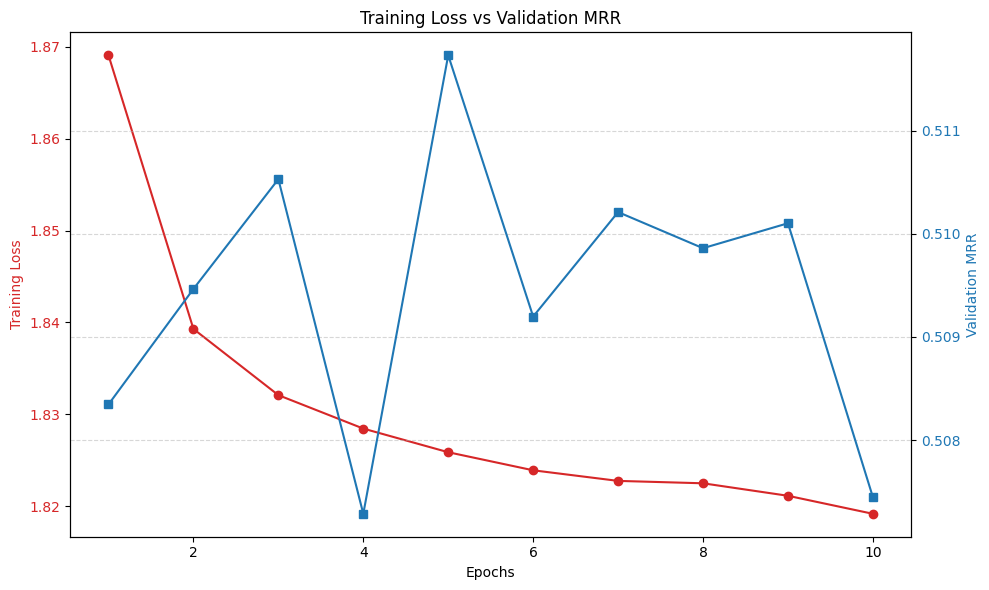

In [14]:
# Plot Results
epochs_range = range(1, len(train_losses) + 1)
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Epochs')
ax1.set_ylabel('Training Loss', color='tab:red')
ax1.plot(epochs_range, train_losses, color='tab:red', marker='o', label='Train Loss')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Validation MRR', color='tab:blue')
ax2.plot(epochs_range, val_mrrs, color='tab:blue', marker='s', label='Val MRR')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Training Loss vs Validation MRR')
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()